# Nosana: 使用可访问的 GPU 运行稳定扩散模型

稳定扩散是一种强大的开源深度学习模型，可以根据文本描述生成详细的图像（文本到图像），基于文本修改现有图像（图像到图像），以及更多功能。它是一种 **latent diffusion model**，通过首先将图像编码为较低维度的 *latent space*，添加噪声，然后使用模型预测并去除该噪声，受您的文本提示指导。

在这个笔记本中，我们将涵盖基本概念，并提供清晰简洁的代码以帮助您入门。我们将探讨：

1.  **Setup**: 安装库和加载 API 密钥。
2.  **Text-to-Image (txt2img)**: 仅从文本提示创建图像。
3.  **Image-to-Image (img2img)**: 使用文本提示修改现有图像。
4.  **Depth-to-Image**: 一种更高级的技术，使用图像的深度图来指导生成。

让我们开始吧！

## 1. 设置

对于像图像生成这样的 GPU 密集型工作负载，您可以轻松使用 Nosana 创建 Jupyter Notebook 环境。

您只需访问 [Nosana dashboard](!https://dashboard.nosana.com/deploy) 并选择 **Pytorch Jupyter Notebook** 模板：

```
docker.io/nosana/pytorch-jupyter:2.0.0
```

这将启动一个支持 GPU 的 Jupyter Notebook 环境，非常适合运行 Stable Diffusion 和其他深度学习模型。

**提示：** 如果您想在本地或通过 VS Code 运行 Jupyter Notebook UI，只需将 Nosana Base URL 复制并粘贴为 Notebook 中的 Kernel URL。这使您可以在自己喜欢的本地环境中使用 Nosana 的远程 GPU 资源。

接下来，安装必要的 Python 库。 `diffusers` 是 Hugging Face 用于处理扩散模型的核心库。 `transformers` 是文本处理组件所需的， `accelerate` 有助于加快处理速度，而 `python-dotenv` 允许我们安全地管理 API 密钥。

您还需要在与此笔记本相同的目录中创建一个 `.env` 文件。此文件将存储您的 Hugging Face API 令牌，该令牌是下载预训练模型所必需的。将以下行添加到您的 `.env` 文件中：

```
HUGGINGFACE_ACCESS_TOKEN='your_api_key_here'
```

In [3]:
%pip install diffusers transformers accelerate python-dotenv Pillow -q

Note: you may need to restart the kernel to use updated packages.


In [4]:
# Install ipywidgets for tqdm progress bars in Jupyter
%pip install ipywidgets --upgrade -q

Note: you may need to restart the kernel to use updated packages.


In [5]:
import torch
from diffusers import AutoPipelineForText2Image, AutoPipelineForImage2Image, StableDiffusionDepth2ImgPipeline
from PIL import Image
import requests
from dotenv import load_dotenv
import os

# Create an .env file and echo your token into the file
load_dotenv()
api_key = os.getenv("HUGGINGFACE_ACCESS_TOKEN")

# Check for GPU availability
device = "cuda" if torch.cuda.is_available() else "cpu"
torch_dtype = torch.float16 if torch.cuda.is_available() else torch.float32

print(f"Using device: {device}")

Using device: cpu


## 2. 文本到图像 (txt2img)

这是Stable Diffusion最常见的用法：从文本描述创建图像。该过程涉及提供一个**prompt**（您想看到的内容），以及可选的**negative prompt**（您想避免的内容）。

关键参数：
- **`prompt`**: 描述所需图像的字符串。
- **`negative_prompt`**: 要从图像中排除的术语字符串。
- **`num_inference_steps`**: 去噪步骤的数量。更多步骤可能导致更高的质量，但所需时间更长。通常25-50之间的值是一个不错的平衡。
- **`guidance_scale`**: 模型应遵循提示的程度。较高的值意味着更严格的遵循。通常，约7.5的值效果很好。

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Image generated in 178.60 seconds


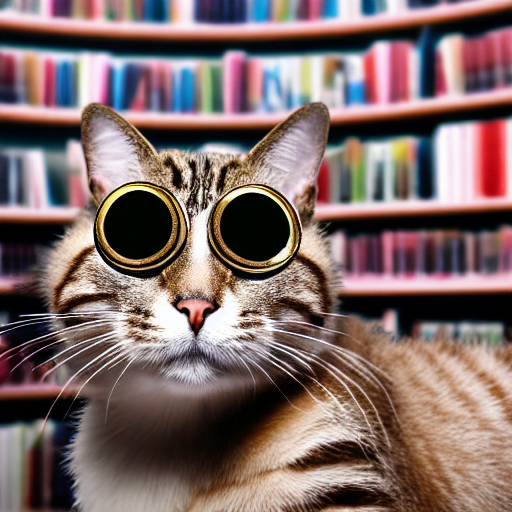

In [9]:
import time
from huggingface_hub import login
from diffusers import AutoPipelineForText2Image
import torch
from IPython.display import display

# Authenticate with Hugging Face Hub
login(token=api_key)

# # Load the text-to-image pipeline with authentication
# txt2img_pipe = AutoPipelineForText2Image.from_pretrained(
#     "stable-diffusion-v1-5/stable-diffusion-v1-5", 
#     torch_dtype=torch.float32,   # assuming you're using GPU
#     use_safetensors=True,
#     token=api_key
# ).to("cuda")   

# Load the text-to-image pipeline with authentication
txt2img_pipe = AutoPipelineForText2Image.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5", 
    torch_dtype=torch.float32,   # CPU must use float32
    use_safetensors=True,
    token=api_key
).to("cpu") # change to cpu or mps

# Define the prompt
prompt = "A cinematic shot of a cat in a library, wearing a monocle, detailed, 8k"
negative_prompt = "blurry, low quality, deformed, ugly"

# Measure time
start_time = time.time()

image = txt2img_pipe(
    prompt=prompt, 
    negative_prompt=negative_prompt, 
    num_inference_steps=30, 
    guidance_scale=7.5
).images[0]

end_time = time.time()
elapsed_time = end_time - start_time

print(f"Image generated in {elapsed_time:.2f} seconds")

# ✅ Display inline in Jupyter
display(image)


## 3. 图像到图像 (img2img)

图像到图像允许您提供一张初始图像和一个提示来指导其转换。这非常适合重新设计图像或更改其内容，同时保留整体构图。

关键的新参数是：
- **`strength`**: 一个介于 0.0 和 1.0 之间的值，用于控制原始图像被改变的程度。较低的值保留了更多的原始图像，而较高的值则给予模型更多的创作自由。

In [ ]:
# Load the image-to-image pipeline
img2img_pipe = AutoPipelineForImage2Image.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5", 
    torch_dtype=torch_dtype, 
    use_safetensors=True
).to(device)

# Load an initial image from a URL
url = "https://upload.wikimedia.org/wikipedia/commons/thumb/e/ea/Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg/1280px-Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg"
init_image = Image.open(requests.get(url, stream=True).raw).resize((768, 600))

prompt = "A futuristic cityscape at night, high-tech, neon lights, in the style of Blade Runner"

# Generate the new image
image = img2img_pipe(
    prompt=prompt,
    image=init_image,
    strength=0.75,
    guidance_scale=7.5
).images[0]

# Display the transformed image
image

## 4. 深度到图像

深度到图像是一种高级技术，其中模型利用初始图像的深度信息生成新图像。这对于保持原始场景的三维结构和构图，同时完全改变其中的风格和对象，具有极大的力量。

模型首先从输入图像估计一个 **depth map**，然后使用它以及您的提示来指导生成过程。

In [ ]:
# Load the depth-to-image pipeline
depth_pipe = StableDiffusionDepth2ImgPipeline.from_pretrained(
    "stabilityai/stable-diffusion-2-depth",
    torch_dtype=torch_dtype,
).to(device)

# Use the same initial image
url = "https://upload.wikimedia.org/wikipedia/commons/thumb/e/ea/Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg/1280px-Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg"
init_image = Image.open(requests.get(url, stream=True).raw).resize((768, 600))

prompt = "Two majestic wolves howling at the moon, fantasy art, detailed"

# Generate the new image using depth information
image = depth_pipe(
    prompt=prompt, 
    image=init_image, 
    strength=0.7
).images[0]

# Display the result
image

## 结论

恭喜你！你已经成功使用 Stable Diffusion 通过三种不同的技术生成了图像。

我们已经覆盖了基础知识，但还有一个广阔的世界等待探索：
- **提示工程**：尝试使用高度详细的提示、艺术家名称和风格。
- **不同模型**：Hugging Face Hub 拥有数千个为特定风格（例如，动漫、照片现实主义）定制的模型。
- **调度器**：`diffusers` 库允许你更换不同的调度器，这可能会影响图像生成的速度和质量。
- **GPU 资源**：通过 Nosana，你可以轻松访问强大的 GPU 资源来运行 Stable Diffusion 和其他深度学习工作负载，无论是在云端还是通过将本地笔记本连接到远程内核。

祝你愉快地扩散！🎉